## Please add a gemini api key in `hidden.evn` file as GEMINI_API_KEY2 

In [1]:
# import openai
# from openai.types import Completion, CompletionChoice, CompletionUsage
import os
import requests
from dotenv import load_dotenv
from scipy.optimize import minimize, Bounds, NonlinearConstraint
from functools import partial, wraps 
import time
import random
    
from Setup_Functions import *
from Class_Structures import *
from Individual import * 
from InterObject import * 
from Global import * 
from Metrics import * 
from Tertiary import * 

load_dotenv("hidden.env") ## IMPORTANT: create a file (hidden.env) with your OpenAI API key 

True

## Set the Prompt 

In [2]:
# scene_descriptor = "A bedroom that is 4m x 5m."
scene_descriptor = "A home office for an AI researcher who loves reading books and coding."

In [3]:
# from google import genai

# client = genai.Client(api_key=os.getenv("GEMINI_API_KEY1"))

# response = client.models.generate_content(
#     model="gemini-2.0-flash",
#     contents="Write a simple python function that adds two numbers",
# )

# response.text

In [4]:
import requests
import os # For potentially getting API key from environment variables


# def call_openai(prompt): 
#     """Helper function to call OpenAI's API and return the response content."""
#     # Define the request payload
#     data = {
#         "model": "gpt-4o",
#         "messages": [{"role": "user", "content": prompt}]
#         }
#     # Make the API call
#     response = requests.post(url, headers=headers, json=data)  
#     # Check the response
#     if response.status_code == 200:
#         response_data = response.json()
#         if "```python" in response_data['choices'][0]['message']['content']:
#             response = (response_data['choices'][0]['message']['content'].split("```python")[1]).split("```")[0]
#         elif "```" in response_data['choices'][0]['message']['content']:
#             response = (response_data['choices'][0]['message']['content'].split("```")[1]).split("```")[0]
#         else: 
#             response = response_data['choices'][0]['message']['content']
#         return response
#     else:
#         print('Failed to get a response', response.text)
#         return 
    

def call_gemini(prompt: str, model: str = "gemini-2.5-flash-preview-05-20"):
# gemini-2.0-flash
    """Helper function to call Google's Gemini API and return the response content."""

    api_key = os.environ.get("GEMINI_API_KEY1")
    url = f"https://generativelanguage.googleapis.com/v1beta/models/{model}:generateContent?key={api_key}"

    data = {
        "contents": [{
            "parts": [{
                "text": prompt
            }]
        }]
    }
    headers = {
        "Content-Type": "application/json"
    }
    try:
        response = requests.post(url, headers=headers, json=data)
        response.raise_for_status()
    except requests.exceptions.RequestException as e:
        print(f"Request failed: {e}")
        if response is not None:
            print(f"Response content: {response.text}")
        return None

    if response.status_code == 200:
        try:
            response_data = response.json()
            generated_text = response_data["candidates"][0]["content"]["parts"][0]["text"]
            if "```python" in generated_text:
                extracted_content = (generated_text.split("```python")[1]).split("```")[0]
            elif "```" in generated_text:
                parts = generated_text.split("```", 2)
                if len(parts) > 1: # Check if there's at least one "```"
                    # If there's content after the first "```" before a potential second "```"
                    # e.g. "```\ncode\n```" or "```lang\ncode\n```"
                    content_inside_blocks = parts[1]
                    # Remove potential language hint from the first line if present
                    if '\n' in content_inside_blocks:
                        extracted_content = content_inside_blocks.split('\n', 1)[1] if content_inside_blocks.startswith(tuple(chr(i) for i in range(ord('a'), ord('z')+1))) else content_inside_blocks
                    else:
                        extracted_content = content_inside_blocks # Could be a single line of code
                    extracted_content = extracted_content

                else: 
                    extracted_content = generated_text
            else:
                extracted_content = generated_text
            
            return extracted_content

        except ValueError:
            print("Failed to decode JSON response.")
            print(f"Response content: {response.text}")
            return None
        except KeyError as e:
            print(f"KeyError when parsing response: {e}. Unexpected response structure.")
            print(f"Full response data: {response_data}")
            return None
    else:
        print(f"Failed to get a successful response. Status code: {response.status_code}")
        print(f"Response text: {response.text}")
        return None


In [5]:
# ## Set up the API calls 
# api_key = os.getenv('OPENAI_API_KEY')
# client = openai.Client(api_key=api_key)
# url = 'https://api.openai.com/v1/chat/completions'
# headers = {
#     'Authorization': f'Bearer {api_key}', 
#     'Content-Type': 'application/json',
#         }


# ## Read in all of the files to be used in the taskimport os
file_path1 = os.path.join("BlankConstraints", "Setup_Functions.py")
with open(file_path1, 'r') as file:
    file_contents1 = file.read()

file_path2 = os.path.join("BlankConstraints", "Individual.py")
with open(file_path2, 'r') as file:
    file_contents2 = file.read()

file_path3 = os.path.join("BlankConstraints", "InterObject.py")
with open(file_path3, 'r') as file:
    file_contents3 = file.read()

file_path4 = os.path.join("BlankConstraints", "Tertiary.py")
with open(file_path4, 'r') as file:
    file_contents4 = file.read()

def remove_identical_lines(function):
    lines = function.split("\n")
    unique_lines = []
    for i in range(len(lines)):

        line = lines[i]
        if line not in unique_lines: 
            unique_lines.append(line)
    return("\n").join(unique_lines)

def check_and_call(func_name, *args, **kwargs):
    """
    Calls the function with the given name if it exists in the global namespace.
    Returns the function's result or 0 if the function does not exist.
    """
    
    if func_name in globals() and callable(globals()[func_name]):
        return globals()[func_name](*args, **kwargs)
    else:
        return 0

def check_calls_decorator(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        result = func(*args, **kwargs)
        return result
    return wrapper

# def call_openai(prompt): 
#     """Helper function to call OpenAI's API and return the response content."""
#     # Define the request payload
#     data = {
#         "model": "gpt-4o",
#         "messages": [{"role": "user", "content": prompt}]
#         }
#     # Make the API call
#     response = requests.post(url, headers=headers, json=data)  
#     # Check the response
#     if response.status_code == 200:
#         response_data = response.json()
#         if "```python" in response_data['choices'][0]['message']['content']:
#             response = (response_data['choices'][0]['message']['content'].split("```python")[1]).split("```")[0]
#         elif "```" in response_data['choices'][0]['message']['content']:
#             response = (response_data['choices'][0]['message']['content'].split("```")[1]).split("```")[0]
#         else: 
#             response = response_data['choices'][0]['message']['content']
#         return response
#     else:
#         print('Failed to get a response', response.text)
#         return 
    


# Set up the Room (all dimensions + fixed features)

In [6]:
start_time = time.time() # Start the time

### Run the room set up calls (LangPrompt1, Prompt1)

In [7]:
lang_prompt1 = """ I am designing the layout for a """ +  scene_descriptor + """. Give me the dimensions of the room, as well as the number of windows, 
doors, and sockets (only add sockets and windows if its appropriate). For each of these, tell me the dimensions in meters, which wall it should be on, as well as where on the wall it should 
be (a value between 0 and 1 determining how far along the wall it should be). Here is an example for a room and window set up: 
{Room: width = 5, length = 6}, {Object type: window, width = 1, length = 0.1, wall = south, position = 3}. The windows and doors should all 
have length 0.1. Ensure that every object has dimensions, position, and wall. No other text please. Just the list with no commentary or explanation. Put the objects in the logical positions and in logical size without overlapping them.
"""

# lang1output = call_gemini(lang_prompt1)
lang1output = call_gemini(lang_prompt1,)
objects = lang1output.split("}, {") if lang1output else []
# print(f"{objects=}")

prompt1 = """The functions in the following file are used to create a room and out objects in it: """ + file_contents1 + """. The room is described 
as """ +  scene_descriptor + """. For every element in this list, """ + str(objects) + """, translate it into a function call using the file attached.
For example, given the room descriptor 'a small kitchen' as well as the list: {Room: width = 5, length = 6}, 
{Object type: window, Number: 1, width = 1, length = 0.1, wall = south, position = 0.3}, the output would be:
kitchen = create_room(5, 6), create_fixed_object(kitchen, 'window', 1, 0.1, 'south', position = 0.3). Return only the python script. 
No other text. Please ensure the correct number of inputs are given for each function.
---
this is the example format bedroom = create_room(4, 5)
create_fixed_object(bedroom, 'window', 1.2, 0.1, 'north', position=0.4)
create_fixed_object(bedroom, 'window', 1.2, 0.1, 'south', position=0.7)
create_fixed_object(bedroom, 'door', 0.8, 0.1, 'east', position=0.2)
create_fixed_object(bedroom, 'socket', 0.1, 0.1, 'west', position=0.5)
create_fixed_object(bedroom, 'socket', 0.1, 0.1, 'east', position=0.8)
['sleeping', 'storage', 'study']

Please do not return the code with incorrect syntax. like this room = def create_room(width, length):
def create_fixed_object(room, name, width, length, wall, position = None):

---
I am executing the code you give to automate the process.
"""


response1 = call_gemini(prompt1,)
# print(f"{response1=} ")

## Account for any additional function calls (of other functions) by only taking the lines in the code that are relevant to the task   
lines = response1.split("\n")
response1 = [i for i in lines if 'create_room' in i]
## If the room is not defined properly, correct it
for line in response1: 
    if '=' not in line: 
        response1 = ['room = ' + line]
for line in lines[1:]: 
    if "create_fixed_object" in line: 
        response1.append(line)

response1 = ("\n").join(response1)

width = (response1.split("create_room("))[1].split(",")[0]
length = (response1.split("create_room("))[1].split(",")[1].split(")")[0]
room_name = (response1.split("create_room("))[0].split("=")[0].strip()
# print(f"{width=}")
lang_prompt2 = """ I am designing the layout of a """ + scene_descriptor + " that is " + width + "m x " + length + """m. Interior designers
suggest that a good layout will have different regions in the room for different functions. What regions should I use, and how many regions 
(minimum is 1 region - small rooms, e.g. 3x3, 2x3, etc, should only have 1 region, small medium sized rooms will have 2, 3x4, 4x3, 4x4, medium will have 3, etc) 
should there be based on the description, as well as the size of the room. Make sure to not add too many regions as this causes overcrowding 
(very few rooms will have more than 4 regions). Return this as a simple bullet list of regions to 
include. Return these in list of priority order. Do NOT add too many regions.
Only return the list of regions. No other information please."""

lang2output = call_gemini(lang_prompt2,)

prompt2 = "Given the room name: " + room_name + ", and the regions: " + lang2output +  """, using the function region_setup defined below, 
initialise each region. For example 'eating region' might output 'region_setup(kitchen, 'eating', 0). Where possible the region name ('eating') should be 
only one word. No other text please, 
only the python script. Don't include the function in the output. The function is: 
def region_setup(room_name, name, index):
    '''A function that initialises the regions in a room randomly.
        Inputs:
        room_name: Room obj (this should be the name of the room)
        name: str, the name of the region e.g 'sleeping'
        index: int, the index of the region (0, 1, 2, ...). First one must be 0, and the rest must be in order.
    '''
    return
"""

response2 = call_gemini(prompt2,)
global_context = globals().copy()
local_context = {}  
exec(response1 + "\n" + response2.replace("'" + room_name + "'", room_name), global_context, local_context)

fixed_objects = ""
for i in range(len(local_context[room_name].fixed_objects)):
    if i < len(local_context[room_name].fixed_objects) - 1:
        fixed_objects +=local_context[room_name].fixed_objects[i].name + ", "
    else: 
        fixed_objects += local_context[room_name].fixed_objects[i].name + "."

region_names = ""
list_region_names = []
for i in range(len(local_context[room_name].regions)):
    if i < len(local_context[room_name].regions) - 1:
        region_names += local_context[room_name].regions[i].name + ", "
        list_region_names.append(local_context[room_name].regions[i].name)  
    else: 
        region_names += local_context[room_name].regions[i].name + "."
        list_region_names.append(local_context[room_name].regions[i].name)
num_primary_objects = len(list_region_names)
num_regions = len(list_region_names)

if "'" + room_name + "'" in response2:
    response2 = response2.replace("'" + room_name + "'", "local_context[room_name]")
elif '"' + room_name + '"' in response2:
    response2 = response2.replace('"' + room_name + '"', "local_context[room_name]")
else: 
    response2 = response2.replace(room_name, "local_context[room_name]")


In [8]:
# objects=['{Room: width = 4, length = 5}\n{Object type: door, width = 0.8, length = 0.1, wall = South, position = 0.2}\n{Object type: window, width = 1.5, length = 0.1, wall = North, position = 0.5}\n{Object type: socket, width = 0.1, length = 0.1, wall = West, position = 0.1}\n{Object type: socket, width = 0.1, length = 0.1, wall = East, position = 0.1}\n{Object type: socket, width = 0.1, length = 0.1, wall = North, position = 0.1}\n{Object type: socket, width = 0.1, length = 0.1, wall = North, position = 0.9}\n{Object type: socket, width = 0.1, length = 0.1, wall = West, position = 0.7}\n{Object type: socket, width = 0.1, length = 0.1, wall = East, position = 0.7}\n{Object type: socket, width = 0.1, length = 0.1, wall = South, position = 0.7}']
# lang1output = '{Room: width = 4, length = 5}\n{Object type: door, width = 0.8, length = 0.1, wall = South, position = 0.2}\n{Object type: window, width = 1.5, length = 0.1, wall = North, position = 0.5}\n{Object type: socket, width = 0.1, length = 0.1, wall = West, position = 0.1}\n{Object type: socket, width = 0.1, length = 0.1, wall = East, position = 0.1}\n{Object type: socket, width = 0.1, length = 0.1, wall = North, position = 0.1}\n{Object type: socket, width = 0.1, length = 0.1, wall = North, position = 0.9}\n{Object type: socket, width = 0.1, length = 0.1, wall = West, position = 0.7}\n{Object type: socket, width = 0.1, length = 0.1, wall = East, position = 0.7}\n{Object type: socket, width = 0.1, length = 0.1, wall = South, position = 0.7}'
# response1="bedroom = create_room(4.0, 5.0)\ncreate_fixed_object(bedroom, 'door', 0.8, 0.1, 'south', position = 0.2)\ncreate_fixed_object(bedroom, 'window', 1.5, 0.1, 'north', position = 0.5)\ncreate_fixed_object(bedroom, 'socket', 0.1, 0.1, 'west', position = 0.1)\ncreate_fixed_object(bedroom, 'socket', 0.1, 0.1, 'east', position = 0.1)\ncreate_fixed_object(bedroom, 'socket', 0.1, 0.1, 'north', position = 0.1)\ncreate_fixed_object(bedroom, 'socket', 0.1, 0.1, 'north', position = 0.9)\ncreate_fixed_object(bedroom, 'socket', 0.1, 0.1, 'west', position = 0.7)\ncreate_fixed_object(bedroom, 'socket', 0.1, 0.1, 'east', position = 0.7)\ncreate_fixed_object(bedroom, 'socket', 0.1, 0.1, 'south', position = 0.7)" 
# lang2output = '*   Sleeping Area\n*   Storage Area\n*   Work/Study Area'
# response2 = "region_setup(local_context[room_name], 'sleeping', 0)\nregion_setup(local_context[room_name], 'storage', 1)\nregion_setup(local_context[room_name], 'work', 2)"
# decoded = response1.encode().decode('unicode_escape')

# # Save to a Python file
# with open("test_Class_Structures.py", "w", encoding="utf-8") as f:
#     f.write(decoded)


In [9]:
print(response1)
print(list_region_names)

home_office = create_room(3.5, 4.5)
create_fixed_object(home_office, 'door', 0.85, 0.1, 'east', position=0.2)
create_fixed_object(home_office, 'window', 1.0, 0.1, 'south', position=0.25)
create_fixed_object(home_office, 'window', 1.0, 0.1, 'south', position=0.75)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'north', position=0.2)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'north', position=0.3)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'north', position=0.4)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'north', position=0.6)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'north', position=0.7)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'north', position=0.8)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'south', position=0.1)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'south', position=0.9)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 'east', position=0.8)
create_fixed_object(home_office, 'socket', 0.1, 0.1, 

# Get the primary objects, as well as all of their constraints. 

In [10]:
lang_prompt3 = f"""The room is described as {scene_descriptor}. Now for each one of the regions: {region_names}, 
what is the most important object to include (keep in mind the room description), and what are its dimensions (give width of back of object and length of side of object but not height) 
in meters. ONLY one object per region. Don't include any objects that go on the walls, e.g. wall art, and don't include any rugs/mats. The size of the room is {width} m x {length}m, bear this in mind when choosing the objects and the size 
of the objects (i.e. put small objects in small rooms). Give no other information please.
Example Output:
Sleeping: Bed, 1.5m x 2m  
Storage: Wardrobe, 1.5m x 0.6m  
Study: Desk, 1.2m x 0.6m
"""

lang3output = call_gemini(lang_prompt3)

print(lang3output)

lang_prompt4 = f"""For each of these objects: {lang3output}, tell me all of the considerations and constraints
for its placement within the room described as {scene_descriptor}, with size: {str(width)}m x {str(length)}m + room_width  that depend only on fixed features in the room like walls, windows, doors, sockets, etc. 
and return these as a bullet list for each object. Include practical things like whether it should be against a wall, or which side should be accessible for use 
(most objects will need an accessible constraint e.g. front of wardrobe needs to be accessible - however very few objects need all of their sides to be accessible 
and very few need their back to be accessible.) or if its tall, maybe it shouldn't block a window, etc. Bear in mind the size of the room, for example if the room is 
large, then the front, left, and right of the bed should be accessible, but if the room is very small, maybe only one side of the bed needs to be accessible.
Only give these constraints and considerations, no other information. You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining. 
Example output
**Sleeping: Bed, 1.5m x 2m**  
- Place against one wall to save space, preferably with the 2m side against the wall.  
- Ensure one long side is accessible for getting in and out of bed.  
- Avoid placing under a window to prevent drafts.  
- Consider accessibility to electrical sockets for charging devices.  
- Ensure it does not block any doors or windows.  

**Storage: Wardrobe, 1.5m x 0.6m**  
- Place against a wall for stability and to save space.  
- Ensure the front is accessible for opening doors/drawers.  
- Avoid placing in direct line of entry to the room to prevent obstruction.  
- Consider proximity to where clothing or items may be frequently used.  
"""
 
lang4output = call_gemini(lang_prompt4)

print(lang4output)

lang_prompt5 = f"""Tell me all of the constraints and considerations between the objects in this list {lang3output} that depend only on each other.
These objects are for different regions, so the constraints should only really be about them being away from each other or near each other, 
nothing more specific. For example, maybe a desk should not be close to a bed, etc. The room is described as {scene_descriptor}, with size: {str(width)} m x {str(length)} m
Only give the constraints and considerations between objects, no other information.You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example output
1. The bed should have enough space around it for ease of access, so avoid placing other objects too close to its sides.

2. The wardrobe doors should be able to open fully without obstruction, so ensure there is enough clearance around it.
"""

lang5output = call_gemini(lang_prompt5)

print(lang5output)

Work: Desk, 1.4m x 0.7m
Reading: Armchair, 0.9m x 0.9m
**Work: Desk, 1.4m x 0.7m**
*   Place the 0.7m side against a wall to maximize usable floor space.
*   The 1.4m front side must be accessible for seating.
*   Ensure proximity to electrical sockets for computer and peripherals.
*   Avoid placing in a position that blocks a door or impedes its full swing.
*   Consider placement relative to windows for natural light, avoiding direct glare on screens.

**Reading: Armchair, 0.9m x 0.9m**
*   Can be placed against a wall to optimize space, or freestanding depending on overall room layout.
*   The front side must be accessible for sitting.
*   Avoid placement that obstructs a door or its swing.
*   Consider proximity to a window for natural reading light.
*   Consider proximity to an electrical socket for a reading lamp or device charging.
1. The desk and the armchair require sufficient separation to establish distinct functional zones, preventing the leisure activity of reading from vis

# Get the Secondary objects, as well as all of their constraints

In [11]:
lang_prompt6 = f"""Given a room described as: {scene_descriptor}, with size:{str(width)}m x {str(length)} m with these regions within 
it: {region_names}, and these primary objects already in it: {lang3output}, what other objects should be added in? 
Give me 0-3 objects per region (depending on the size of the room - fewer objects for smaller rooms, and more objects for larger room) that should be added 
into the room (so make sure they are the most appropriate/necessary objects for their regions). Ensure to add objects that are necessary,e.g. if there's a desk, always add a 
desk chair. Try not to give objects that are redundant, e.g. if there is a tv stand in the room, you don't need a media console.
Objects should be things like furniture or plants or other objects that sit on the floor.
For each one, make sure that they make sense to go into one of the regions, and tell me which region they should go into. There can be more than one of 
each object kind (eg. multiple dining chairs or multiple nightstands) so make sure to specify how many of each object. Make sure to also give the dimensions of every object in meters (width of the back 
of the object and length of the side of the object but NOT HEIGHT). Remove any objects that are not placed directly on the floor, e.g. table lamp,
and remove any objects that are mounted on the wall (e.g. paintings). Don't include rugs. 
Only give objects that get placed onto the floor. Give no other text in the response. 
Only the list of objects.You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example Output: 
1. Sleeping:  
   - Nightstand, 0.5m x 0.4m  
   - Dresser, 1.0m x 0.5m  

2. Storage:  
   - Shoe rack, 0.8m x 0.3m  

3. Study:  
   - Desk chair, 0.5m x 0.5m
"""

lang6output = call_gemini(lang_prompt6)

print(lang6output)

lang_prompt7 = f"""For each of these objects {lang6output}, tell me all of the considerations and constraints for its placement 
within the room that depends only on fixed features in the room like walls, windows, doors, sockets, etc. (return these as a bullet list for each object). 
Include practical things like whether it should be against a wall and what side of the object (one of: left, right, back, front) or if it should be
against a wall, or which side should be accessible for use (Most objects will have an accessible constraint -
 this would be something like the wardrobe needs to be accessible from the front so that the doors can open, or the bed needs to be accessible from the sides
 - but only give necessary accessible constraints. If an object can have its side against something, then don't say its side needs to be accessible 
 e.g. for a nightstand, etc). The room is described as {scene_descriptor}. Don't include any constraints that depend on other objects. 
 Only give these constraints and considerations, no other information.You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining. 
 Example Output:
 1. Nightstand, 0.5m x 0.4m:
   - Consider placing against a wall (back side).

2. Dresser, 1.0m x 0.5m:
   - Place against a wall (back side).
   - Front side should be accessible for use (to access drawers).

3. Shoe rack, 0.8m x 0.3m:
   - Consider placing against a wall (back side).
   - Front side should be accessible for use (to place or remove shoes).

 """
lang7output = call_gemini(lang_prompt7)

print(lang7output)

lang_prompt8 = f"""Tell me all of the constraints and considerations between the objects in this list {lang6output} as well as 
in this list {lang3output}. For example, a desk chair should have its front against the front of the desk, or the left side of one 
of the nightstands should be against the right side of the bed, etc.  Be specific with relationships between objects to include sides (one of: left, right, back, front) 
if appropriate, or minimum/maximum distances between objects etc. The room is described as {scene_descriptor}.
Only give the constraints and considerations between objects, no other information.You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example Output:
"""

lang8output = call_gemini(lang_prompt8)

print(lang8output)

1. Work:
   - Desk chair, 0.6m x 0.6m
   - Storage cabinet, 0.6m x 0.4m
   - Floor plant, 0.3m x 0.3m

2. Reading:
   - Bookshelf, 0.9m x 0.3m
   - Side table, 0.4m x 0.4m
   - Floor lamp, 0.3m x 0.3m
1. Desk chair, 0.6m x 0.6m:
   - Consider placement away from walls to allow movement.
   - All sides should be accessible for movement.

2. Storage cabinet, 0.6m x 0.4m:
   - Place against a wall (back side).
   - Front side should be accessible for use (to open doors/drawers).

3. Floor plant, 0.3m x 0.3m:
   - Consider placing near a window for light.
   - Consider placement to avoid obstructing doors.

4. Bookshelf, 0.9m x 0.3m:
   - Place against a wall (back side).
   - Front side should be accessible for use (to access books).
   - Consider placement to avoid blocking windows or doors.

5. Side table, 0.4m x 0.4m:
   - Consider placing against a wall (back side).

6. Floor lamp, 0.3m x 0.3m:
   - Requires placement near an electrical socket.
   - Consider placing near a wall (back 

# Get the Tertiary Objects (Decorations!)

In [12]:
lang_prompt9 = f"""Given a room described as: {scene_descriptor}, with size: {str(width)} m x {str(length)} m with these regions within 
it: {region_names}, and these objects already in it: {lang3output} {lang6output}, 
suggest any rugs or other decorations or objects (these are things that go on top of other objects) that should be placed in the room.
For example, a tv to go on the tv unit, a painting above the bed, a table lamp on the nightstand, or a chandelier over the dining table, a 
computer to go on the desk, etc. Don't give any furniture or objects that go on the floor (other than rugs).
Everything should either go on the wall, on the ceiling, or on top of a piece of furniture. Don't include curtains.
Tell me the dimensions of the objects (width and length not height - in meters). If it is a wall object, its length should be 0.1m. 
Tell me how they should be placed (with respect to one object. e.g. painting should be placed near the dining table or lamp should 
be placed on a nightstand). Don't give too many objects and don't include multi-object objects e.g. gallery walls or shelves. You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example Output:

1. **Sleeping Area:**
   - **Table Lamp:** 0.2m x 0.2m. Place it on the nightstand.
   - **Painting:** 0.8m x 0.1m. Hang it above the bed.

2. **Storage Area:**
   - **Decorative Box:** 0.4m x 0.3m. Place it on top of the dresser for additional storage and aesthetics.

3. **Study Area:**
   - **Desk Organizer:** 0.3m x 0.2m. Place it on the desk to keep stationery and small items organized.
   - **Wall Clock:** 0.4m x 0.1m. Mount it on the wall above the desk for easy visibility while studying.

"""

lang9output = call_gemini(lang_prompt9)

print(lang9output)

1.  **Work Area:**
    *   **Rug:** 1.6m x 2.0m. Place it under the desk and desk chair.
    *   **Computer Monitor:** 0.6m x 0.2m. Place it on the desk.
    *   **Desk Lamp:** 0.2m x 0.2m. Place it on the desk.
    *   **Desk Organizer:** 0.3m x 0.2m. Place it on the desk.
    *   **Decorative Object:** 0.2m x 0.2m. Place it on top of the storage cabinet.
    *   **Wall Art:** 0.8m x 0.1m. Hang it above the desk.

2.  **Reading Area:**
    *   **Rug:** 1.2m x 1.6m. Place it under the armchair and side table.
    *   **Bookends:** 0.1m x 0.1m. Place them on the bookshelf.
    *   **Small Vase:** 0.15m x 0.15m. Place it on the side table.
    *   **Throw Pillow:** 0.4m x 0.4m. Place it on the armchair.
    *   **Wall Art:** 0.7m x 0.1m. Hang it near the armchair.


# Cleaning of the Constraints

In [13]:
cleaning_prompt1 = f"""I am going to give you a list of constraints. I want you to merge any similar constraints and also remove any duplicate constraints. 
Each constraint should be simplified, so that it is said in the most basic terms. I want you to remove any constraints that are contradictory e.g. should be near a window 
AND should be away from a window. If there is an "or" statement in the constraint, choose one of the options. Finally, each bullet constraint should only specify one constraint. For example if there is a bullet point that says and object should not block windows 
and doors, change this into 2 bullets - one for blocking doors, and one for blocking windows. Remove any constraints that have if statements, and any
that involve height. If there are constraints for objects to be accessible from all sides that are unnecessary, 
change them to be which sides you think ARE necessary. If there are constraints with "or" in them, choose between the options. 
Return the list of cleaned constraints. Here is the list of constraints: {lang4output}
You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example output:
**Sleeping: Bed, 1.5m x 2m**  
- Place against one wall to save space.  
- Ensure one long side is accessible for getting in and out of bed.  
- Ensure accessibility to electrical sockets for charging devices.  
- Ensure it does not block any doors.

**Storage: Wardrobe, 1.5m x 0.6m**  
- Place against a wall for stability and to save space.  
- Ensure the front is accessible for opening doors/drawers.  
- Avoid placing in direct line of entry to the room.  
- Consider proximity to where clothing or items may be frequently used.

"""

cleaning1output = call_gemini(cleaning_prompt1)


cleaning_prompt2 = f"""I am going to give you a list of constraints. I want you to merge any similar constraints and also remove any duplicate constraints. 
Each constraint should be simplified, so that it is said in the most basic terms. I also want you to remove any constraints that are contradictory e.g. should be near a window 
AND should be away from a window.  If there is an "or" statement in the constraint, choose one of the options.Finally, each bullet constraint should only specify one constraint. For example if there is a bullet point that says and object should be away 
from windows and doors, change this into 2 bullets - one for away from doors, and one for away from windows. Remove any constraints that have if statements, and any 
that involve height. If there are constraints with "or" in them, choose between the options. 
Return the list of cleaned constraints. Here is the list of constraints:{lang5output}You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example Output:
- The bed should have enough space around it for ease of access.
- Avoid placing objects too close to the sides of the bed.
- The wardrobe doors should be able to open fully without obstruction.
- Ensure there is enough clearance around the wardrobe.
- The desk should have a good source of light, either natural or artificial.
"""

cleaning2output = call_gemini(cleaning_prompt2)

cleaning_prompt3 = f"""I am going to give you a list of constraints. I want you to merge any similar constraints and also remove any duplicate constraints. 
Each constraint should be simplified, so that it is said in the most basic terms. I also want you to remove any constraints that are contradictory e.g. should be near a window 
AND should be away from a window. If there is an "or" statement in the constraint, choose one of the options. Finally, each bullet constraint should only specify one constraint. For example if there is a bullet point that says and object should be away 
from windows and doors, change this into 2 bullets - one for away from doors, and one for away from windows. Remove any constraints that have if statements, and any 
that involve height. If there are constraints for objects to be accessible from all sides that are unnecessary, 
change them to be which sides you think ARE necessary. If there are constraints with "or" in them, choose between the options. 
Return the list of cleaned constraints.  Here is the list of constraints: {lang7output}
You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example Output:

1. Nightstand, 0.5m x 0.4m:
   - Place against a wall (back side).

2. Dresser, 1.0m x 0.5m:
   - Place against a wall (back side).
   - Front side should be accessible.

3. Shoe rack, 0.8m x 0.3m:
   - Place against a wall (back side).
   - Front side should be accessible.

"""

cleaning3output = call_gemini(cleaning_prompt3)


cleaning_prompt4 = f"""I am going to give you a list of constraints. I want you to merge any similar constraints and also remove any duplicate constraints. 
Each constraint should be simplified, so that it is said in the most basic terms. I also want you to remove any constraints that are contradictory e.g. should be near a window 
AND should be away from a window.  If there is an "or" statement in the constraint, choose one of the options. Finally, each bullet constraint should only specify one constraint. For example if there is a bullet point that says and object should be away 
from windows and doors, change this into 2 bullets - one for away from doors, and one for away from windows. Remove any constraints that have if statements, and any 
that involve height. Return the list of cleaned constraints. If there are constraints with "or" in them, choose between the options. 
Here is the list of constraints: {lang8output}You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example Output:

1. Sleeping:
   - The Nightstand should be against the side of the Bed.
   - The Dresser should be placed with its back against a wall, not directly adjacent to the Bed, maintaining at least 0.5m of clearance.

2. Storage:
   - The Shoe rack should be placed with its back against a wall, not blocking pathways or access to other furniture.
   - The Wardrobe's back should be against a wall, with at least 0.6m clearance in front.

3. Study:
   - The Desk chair should have enough space to pull out, ideally at least 0.5m of clearance.
   - The Desk's back should be against a wall.
"""

cleaning4output = call_gemini(cleaning_prompt4)


p_ind_cons = cleaning1output
p_io_cons = cleaning2output
s_ind_cons = cleaning3output
s_io_cons = cleaning4output

In [14]:
print(p_ind_cons)

**Work: Desk, 1.4m x 0.7m**
- Place the 0.7m side against a wall.
- Ensure the 1.4m side is accessible for seating.
- Ensure proximity to electrical sockets.
- Ensure it does not block a door.
- Place near a window for natural light.

**Reading: Armchair, 0.9m x 0.9m**
- Place against a wall.
- Ensure the front side is accessible for sitting.
- Ensure it does not block a door.
- Place near a window for natural light.
- Ensure proximity to an electrical socket.


In [15]:
print(p_io_cons)

- Separate the desk and armchair for distinct functional zones.
- Ensure space for full desk chair movement.


In [16]:
print(s_ind_cons)

1. Desk chair, 0.6m x 0.6m:
   - Away from walls.
   - Accessible from front and sides.

2. Storage cabinet, 0.6m x 0.4m:
   - Place back against a wall.
   - Front side accessible.

3. Floor plant, 0.3m x 0.3m:
   - Near a window.
   - Away from doors.

4. Bookshelf, 0.9m x 0.3m:
   - Place back against a wall.
   - Front side accessible.
   - Away from windows.
   - Away from doors.

5. Side table, 0.4m x 0.4m:
   - Place back against a wall.

6. Floor lamp, 0.3m x 0.3m:
   - Near an electrical socket.
   - Near a wall.
   - Away from doors.
   - Away from windows.


In [17]:
print(s_io_cons)

1. Desk chair:
   - Desk chair front aligns with Desk front.
   - Desk chair back minimum clearance: 0.9m.
   - Desk chair slides under Desk.
   - Desk chair movement path minimum clearance to Storage cabinet front: 0.6m.
   - Desk chair movement path minimum clearance to Floor plant side: 0.3m.

2. Storage cabinet:
   - Storage cabinet left against Desk right.
   - Storage cabinet front is accessible from Desk chair.
   - Storage cabinet back against a wall.

3. Floor plant (Work area):
   - Floor plant side against Desk side.
   - Floor plant front minimum distance to primary pathway: 0.6m.

4. Bookshelf:
   - Bookshelf back against a wall.
   - Bookshelf front faces accessible space.
   - Bookshelf front minimum distance to Armchair front: 1.5m.
   - Bookshelf front maximum distance to Armchair front: 3m.
   - Bookshelf left against Armchair right minimum distance: 0.5m.
   - Bookshelf front minimum distance to general pathway: 0.9m.

5. Side table:
   - Side table left against Armc

# Add all the objects into the room 
### Region by region. 

In [18]:
prompt4 = f"""Given this list of primary objects: {lang3output}, and this list of secondary objects: {lang6output}, use the file attached to create the objects with the correct parameters.
The room name is: {room_name}, the region names are: {str(list_region_names)}. The room is already set up, only add in the objects using the 'create_moving_object' function. 
Ensure that each objects index is unique and that the indices begin from 0. The objects should be added in the correct regions. Add in all of the primary objects first.
This is the file: {file_contents1}. No extra text, only the function calls. Don't have 'python' at the start of the code. Do not define ANY functions, only call them.
You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.

"""

response4 = call_gemini(prompt4)     
lines = response4.split("\n")
response4_1 = []
for line in lines: 
    if "create_moving_object" in line: 
        response4_1.append(line)
response4_1 = ("\n").join(response4_1)

response4_1 = response4_1.replace("create_moving_object(room,", "create_moving_object(" + room_name + ",")
response4 = remove_identical_lines(response4_1).replace("(" + room_name, "(local_context[room_name]")

strings = response4.split("create_moving_object(local_context[room_name],")
primary_objects = []
for string in strings[1:]:
    if "'" in string: 
        primary_objects.append(string.split("'")[1])
    else:
        primary_objects.append(string.split('"')[1])

print(response4)

create_moving_object(local_context[room_name], 'desk', 1.4, 0.7, 'Work', 0)
create_moving_object(local_context[room_name], 'armchair', 0.9, 0.9, 'Reading', 1)
create_moving_object(local_context[room_name], 'desk chair', 0.6, 0.6, 'Work', 2)
create_moving_object(local_context[room_name], 'storage cabinet', 0.6, 0.4, 'Work', 3)
create_moving_object(local_context[room_name], 'floor plant', 0.3, 0.3, 'Work', 4)
create_moving_object(local_context[room_name], 'bookshelf', 0.9, 0.3, 'Reading', 5)
create_moving_object(local_context[room_name], 'side table', 0.4, 0.4, 'Reading', 6)
create_moving_object(local_context[room_name], 'floor lamp', 0.3, 0.3, 'Reading', 7)


In [19]:
object_creations = ['' for i in range(num_regions + 1)]
lines = response4.split("\n")
for i in range(num_regions):
    sub_lines = [line for line in lines if "'" + list_region_names[i] + "'," in line or  '"' + list_region_names[i] + '",' in line]
    object_creations[0] = "\n".join([object_creations[0], sub_lines[0]])
    object_creations[i + 1] = "\n".join(sub_lines[1:])

primary_objects = []
secondary_objects = []
primary_object_indices = []

for name in list_region_names:
    lines = [i for i in response4.split("\n") if ((name + "'," in i or name + '",' in i) and 'create_moving_object' in i)]
    if "'" in lines[0]: 
        name = lines[0].split("'")[1]
    else:
        name = lines[0].split('"')[1]
    index = int(lines[0].split(", ")[-1].split(")")[0])
    primary_object_indices += [index]
    primary_objects += [name]

    for line in lines[1:]:
        if "'" in line: 
            name = line.split("'")[1]
        else:
            name = line.split('"')[1]
        secondary_objects += [name]

secondary_object_indices = [i for i in range(len(secondary_objects) + len(primary_objects)) if i not in primary_object_indices]

In [20]:
print(primary_object_indices, secondary_object_indices)
print(primary_objects, secondary_objects)

[0, 1] [2, 3, 4, 5, 6, 7]
['desk', 'armchair'] ['desk chair', 'storage cabinet', 'floor plant', 'bookshelf', 'side table', 'floor lamp']


# Find the Primary Optimization Functions

In [21]:
indent = '    '

In [22]:
def get_primary_function_calls():

    prompt5 = f"""Given the room_name {room_name} as well as the primary objects: {str(primary_objects)}, their 
    indices {str(primary_object_indices)} and these constraints: {p_ind_cons}, using the script attached, transform each constraint into a SINGLE 
    function call that will ensure that the primary objects are set up correctly. Match each constraint to the closest function in the
    script file by using the docstrings. Ensure that every constraint is mapped to a function call. Here is the first script: {file_contents2}. 
    For the second script, I want you to transform each pairwise constraint into a function call.
    Here is the second script: {file_contents3}, and here is the list of pairwise constraints: {p_io_cons}. I want 
    the output to begin with: def optimize_primary_objects(positions, room): \n output = 0,  followed by each constraint function call added to the output, 
    and then the output returned (everyline should begin with 'output +=' except for the final line). Go object by object, and then pairwise. 
    No extra text please, only the functions and the output. If there is only 1 primary object, there should be no pairwise calls.
    Do not define ANY functions, only call them. ENSURE that all parameters match docstrings.
    You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
    """

    response_data5 = call_gemini(prompt5)

    if "```" in response_data5:
        list_objects = (response_data5).split("\n")[1:-1]
        response5_1 = ""
        for i in range(len(list_objects)):
            response5_1 += list_objects[i] + "\n"
    else: 
        
        response5_1 = response_data5

    response5 = remove_identical_lines(response5_1).replace("'''", "").replace("```", "")
    lines = response5.split("\n")
    new_lines = []
    for i in range(len(lines)): 
        if "ind_in_region" in lines[i]: 
            continue
        if "output" in lines[i]: 
            new_lines += [indent + "output" + lines[i].split("output")[1]]
            if '=' not in lines[i]: 
                new_lines[-1] = indent + "\n"

        else: 
            new_lines += [lines[i]]
    
    response5 = ("\n").join(new_lines)
    whole_calls = [indent + "output += wall_attraction(positions, room)\n" + indent, "output += in_bounds(positions, room)\n" + indent, "output += no_overlap(positions, room)\n" + indent, "output += aligned(positions, room)\n" + indent, "output += 10*balanced(positions, room)\n" + indent + "return output"]
    new = response5.split("return")[0] 
    for call in whole_calls: 
        new += call 
    response5 = new

    lines = response5.split("\n")
    for line in lines[1:]: 
        if "ind_" in line or "io_" in line: 
            function_name = (line.split("(")[0]).split("= ")[1].strip()
            args = (line.split("(")[1]).split(")")[0]
            new_line = line.split("+=")[0] + " += check_and_call('" + function_name + "', " + args + ")"       
            lines[lines.index(line)] = new_line

    primary_function = ("\n").join(lines)
    print(primary_function)     
        

    
    return primary_function

primary_function = get_primary_function_calls()
while ("ind_" not in primary_function or "io_" not in primary_function) and len(primary_object_indices) > 1:
    print("Failure to get individual AND inter object function calls. Rerunning.")
    primary_function = get_primary_function_calls()

def optimize_primary_objects(positions, room):
    output = 0
    output  += check_and_call('ind_next_to_wall', positions, room, object_index=0)
    output  += check_and_call('ind_accessible', positions, room, object_index=0, sides=['front'], min_dist=1.2)
    output  += check_and_call('ind_close_to_fixed_object', positions, room, object_index=0, fixed_object_type='socket')
    output  += check_and_call('ind_not_block_fixed_object', positions, room, object_index=0, fixed_object_type='door')
    output  += check_and_call('ind_close_to_fixed_object', positions, room, object_index=0, fixed_object_type='window')
    output  += check_and_call('ind_next_to_wall', positions, room, object_index=1)
    output  += check_and_call('ind_accessible', positions, room, object_index=1, sides=['front'])
    output  += check_and_call('ind_not_block_fixed_object', positions, room, object_index=1, fixed_object_type='door')
    output  += check_and_call('ind_close_to_fixed_object', positions, room, object_i

In [23]:
primary_accessible_constraints = []
lines = primary_function.split("\n")
for line in lines: 
    if "ind_accessible" in line: 
        primary_accessible_constraints.append("output" + line.split("output")[1])

# Get the Secondary Optimization Functions

In [24]:
objects_per_region =[[] for i in range(num_regions)]
lines = response4.split("\n")
for i in range(len(lines)):
    for j in range(num_regions):
        if list_region_names[j] + "'," in lines[i] or list_region_names[j] + '",' in lines[i]:
            object_index = int(lines[i].split(", ")[-1].split(")")[0])
            objects_per_region[j].append(object_index)
        
object_regions = [list_region_names[k] for k in range(num_regions) for i in objects_per_region[k][1:]]
obj_ind = [(secondary_objects[i], secondary_object_indices[i], object_regions[i]) for i in range(len(secondary_objects))]


In [25]:
def get_secondary_function_calls():
    prompt6 = f"""Given the primary objects: {str(primary_objects)} and their indices: {str(primary_object_indices)}, as well as the secondary
    objects, along with their indices and their regions: {str(obj_ind)},  their individual 
    constraints: {s_ind_cons}, and these are the region names: {region_names}.  Using the script attached, transform each constraint into a SINGLE 
    function call that will ensure that the primary objects are set up correctly. Match each constraint to the closest function in the
    script file by using the docstrings. Ensure that every constraint is mapped to a function call.
    Here is the first script: {file_contents2}. For the second script, I want you to transform each pairwise constraint into a SINGLE function call. 
    Here is the second script: {file_contents3}, and here is the list of pairwise constraints: {s_io_cons}. 
    I want the output to begin with: ’def optimize_secondary_objects(positions, room): \n output = 0\n’, followed by each constraint function call 
    added to the output, (each line should begin with 'output +='). Go object by object, and then pairwise. 
    Also ensure to use ind_in_region for each object. Do not define ANY functions, only call them. No extra text please, only the functions and the output.
    You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.

    """

    response6 = call_gemini(prompt6)

    if "```" in response6:
        list_objects = (response6).split("\n")[1:-1]
        response6_1 = ""
        for i in range(len(list_objects)):
            response6_1 += list_objects[i] + "\n"
    else: 
        
        response6_1 = response6
    
    indent1 = (response6_1.split("output")[0]).split("\n")[-1]

    response6 = "def optimize_secondary_objects(positions, room):\n" + indent + "output = 0\n"
    response6 += indent + "\n" + (("\n").join((response6_1.split("return")[0]).split("\n")[2:])).replace(indent1, indent) + "\n" + indent + "return output \n"

    whole_calls = ["output += wall_attraction(positions, room)\n" + indent, "output += in_bounds(positions, room)\n" + indent, "output += no_overlap(positions, room)\n" + indent, "output += aligned(positions, room)\n" + indent + "return"]
    new = response6.split("return")[0] 
    for call in whole_calls: 
        new += call 
    new += response6.split("return")[1]
    response6 = new

    lines = response6.split("\n")
    for line in lines[1:]: 
        if "ind_" in line or "io_" in line: 
            function_name = (line.split("(")[0]).split("= ")[1].strip()
            args = (line.split("(")[1]).split(")")[0]
            new_line = line.split("+=")[0] + " += check_and_call('" + function_name + "', " + args + ")"       
            lines[lines.index(line)] = new_line

    response6 = ("\n").join(lines)
    print(response6)


    return response6, indent1

response6, indent1 = get_secondary_function_calls()
while "ind_" not in response6:
    print("Failure to get individual function calls. Rerunning.")
    response6, indent1  = get_secondary_function_calls()
while "io_" not in response6:
    print("Failure to get Inter Object function calls. Rerunning.")
    response6, indent1  = get_secondary_function_calls()


def optimize_secondary_objects(positions, room):
    output = 0
    
    # Region Constraints
    output  += check_and_call('ind_in_region', positions, room, 0, 'Work')
    output  += check_and_call('ind_in_region', positions, room, 1, 'Reading')
    output  += check_and_call('ind_in_region', positions, room, 2, 'Work')
    output  += check_and_call('ind_in_region', positions, room, 3, 'Work')
    output  += check_and_call('ind_in_region', positions, room, 4, 'Work')
    output  += check_and_call('ind_in_region', positions, room, 5, 'Reading')
    output  += check_and_call('ind_in_region', positions, room, 6, 'Reading')
    output  += check_and_call('ind_in_region', positions, room, 7, 'Reading')

    # Individual Object Constraints

    # 1. Desk chair (index 2)
    output  += check_and_call('ind_not_against_wall', positions, room, 2)
    output  += check_and_call('ind_accessible', positions, room, 2, ['front', 'left', 'right'])
    output  += check_and_call('ind_accessible', position

In [26]:
secondary_functions = ['' for i in range(num_regions)]
lines = response6.split("\n")

for i in range(num_regions - 1, -1, -1):
    function = ("\n").join(lines[:2]) + "\n" + indent
    function += ("\n" + indent).join(primary_accessible_constraints[:i + 1])
        

    for obj_index in objects_per_region[i]:
        for line in lines: 
            if " " + str(obj_index) + "," in line or " " + str(obj_index) + ")" in line: 
                if line not in function:
                    function += "\n" + line
            
    for line in lines: 
        if "no_overlap" in line:
            function += "\n" + line
        if "in_bounds" in line:
            function += "\n" + line
        if "aligned" in line: 
            function += "\n" + line
        if "return" in line: 
            function += "\n" + line

    secondary_functions[i] =  function

In [27]:
for i in secondary_functions: 
    print(i)

def optimize_secondary_objects(positions, room):
    output = 0
    output  += check_and_call('ind_accessible', positions, room, object_index=0, sides=['front'], min_dist=1.2)
    output  += check_and_call('ind_in_region', positions, room, 0, 'Work')
    output  += check_and_call('ind_next_to_wall', positions, room, 0)
    output  += check_and_call('ind_accessible', positions, room, 0, sides=['front'])
    output  += check_and_call('ind_accessible', positions, room, 0, sides=['left'])
    output  += check_and_call('ind_accessible', positions, room, 0, sides=['right'])
    output  += check_and_call('ind_accessible', positions, room, 0, sides=['front'], min_dist=1.5)
    output  += check_and_call('io_next_to', positions, room, 2, 0, side1='front', side2='front')
    output  += check_and_call('io_next_to', positions, room, 3, 0, side1='left', side2='right')
    output  += check_and_call('io_next_to', positions, room, 4, 0)
    output  += check_and_call('io_away_from', positions, room, 1, 

In [28]:
new_secondary_functions = secondary_functions.copy()
secondary_accessible_constraints = [[] for i in range(num_regions)]
for region in range(num_regions):
    for i in secondary_functions[region].split("\n"):
        if "ind_accessible" in i:
            secondary_accessible_constraints[region].append(("output" + i.split("output")[1]).replace(indent1, indent))

    secondary_accessible_constraints[region] = "\n" +("\n").join(secondary_accessible_constraints[region])

for i in range(num_regions):
    if i > 0: 
        for j in secondary_accessible_constraints[i - 1].split("\n"):
            if j not in secondary_accessible_constraints[i]:
                secondary_accessible_constraints[i] += ("\n" + j).replace(indent1, indent)

secondary_functions = new_secondary_functions.copy()

## Get the Tertiary Object Function

In [29]:
prompt7 = f"""Given this list of tertiary objects: {lang9output} use the function attached to create the objects with the correct parameters.
The room name is: {room_name}. The room description is: {scene_descriptor}. The room is already set up, only add in the objects using the 'create_tertiary_object' function.
Ensure that each objects index is unique and that the indices begin from 0. The object names should be simple and short. The objects should be given the correct tertiary type 
(ceiling, floor, wall, or table). Wall objects should all have length 0.1m. Ensure that th parameters are set correctly. This is the function: """ + """
def create_tertiary_object(room, name, width, length, tertiary, index):
        " A function that creates and places a tertiary object 
        Inputs:
        room: Room for the object to be put in
        name: str, name of the object all lowercase. E.g. 'painting'
        width: float, width of the object (m)
        length: float, length of the object (m)
        tertiary: str, tertiary object type, one of "wall" (for objects that go on the wall e.g. painting),
                 "floor" (for objects that go on the floor e.g. rug), "ceiling" (for objects that go on the ceiling e.g. chandelier), 
                 "table" (for objects that go on a table e.g. lamp). 
        index: int, index of the object in the room's tertiary object list

    " """ 
prompt7 += """No extra text, only the function calls. Don't have 'python' at the start of the code. Do not define ANY functions, only call them.
You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example Output:
"""

response_data7 = call_gemini(prompt7)

if "```" in response_data7:
    list_objects = (response_data7).split("\n")[1:-1]
    response7_1 = ""
    for i in range(len(list_objects)):
        response7_1 += list_objects[i] + "\n"
    
lines = response_data7.split("\n")
response7_1 = []
for line in lines: 
    if "create_tertiary_object" in line: 
        response7_1.append(line)
response7_1 = ("\n").join(response7_1)

response7_1 = response7_1.replace("create_tertiary_object(room,", "create_tertiary_object(" + room_name + ",")
if "'" + room_name + "'" in response7_1:
    response7 = remove_identical_lines(response7_1).replace("'" + room_name + "'", 'local_context[room_name]')
elif '"' + room_name + '"' in response7_1:
    response7 = remove_identical_lines(response7_1).replace('"' + room_name + '"', 'local_context[room_name]')
elif room_name in response7_1:
    response7 = remove_identical_lines(response7_1).replace("(" + room_name, '(local_context[room_name]')



tertiary_indices = [i for i in range(len(response7.split("\n")))]
tertiary_objects = []
lines = response7.split("\n")
for line in lines:
    if "'" in line: 
        tertiary_objects.append(line.split("'")[1])
    else:
        tertiary_objects.append(line.split('"')[1])

print(response7)

create_tertiary_object(room=home_office, name='rug', width=1.6, length=2.0, tertiary='floor', index=0)
create_tertiary_object(room=home_office, name='monitor', width=0.6, length=0.2, tertiary='table', index=1)
create_tertiary_object(room=home_office, name='lamp', width=0.2, length=0.2, tertiary='table', index=2)
create_tertiary_object(room=home_office, name='organizer', width=0.3, length=0.2, tertiary='table', index=3)
create_tertiary_object(room=home_office, name='decoration', width=0.2, length=0.2, tertiary='table', index=4)
create_tertiary_object(room=home_office, name='wall_art', width=0.8, length=0.1, tertiary='wall', index=5)
create_tertiary_object(room=home_office, name='rug', width=1.2, length=1.6, tertiary='floor', index=6)
create_tertiary_object(room=home_office, name='bookends', width=0.1, length=0.1, tertiary='table', index=7)
create_tertiary_object(room=home_office, name='vase', width=0.15, length=0.15, tertiary='table', index=8)
create_tertiary_object(room=home_office, na

In [30]:
tertiary_objects = []
lines = response7.split("\n")
for line in lines: 
    if '"' in line: 
        tertiary_objects.append(line.split('"')[1])
    else: 
        tertiary_objects.append(line.split("'")[1])
print(tertiary_objects)

['rug', 'monitor', 'lamp', 'organizer', 'decoration', 'wall_art', 'rug', 'bookends', 'vase', 'pillow', 'wall_art']


In [31]:
def get_tertiary_function_calls():
    prompt8 = f"""Given all the objects in the room: {str(primary_objects)} {str(secondary_objects)} and their indices: {str(primary_object_indices)} {str(secondary_object_indices)}
    as well as the region names: {region_names}. Here are the tertiary objects and how they should be placed: {str(tertiary_objects)} {lang9output}.
    These are there indices: {str(tertiary_indices)}. Using the script attached, transform each placement into a SINGLE function call that will ensure that 
    the tertiary objects are placed correctly. If there is not a function that fits, then choose another. 
    Here is the  script: {file_contents4}. I want the output to begin with: ’def optimize_tertiary_objects(positions, room): \n output = 0\n’, followed by each function call 
    added to the output, (each line should begin with 'output +='). Do not define ANY functions, only call them. No extra text please, 
    only the functions and the output.    You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
"""

    response8 = call_gemini(prompt8)

    if "```" in response8:
        list_objects = (response8).split("\n")[1:-1]
        response8_1 = ""
        for i in range(len(list_objects)):
            response8_1 += list_objects[i] + "\n"
    else: 
        
        response8_1 = response8
    
    indent1 = (response8_1.split("output")[0]).split("\n")[-1]

    response8 = "def optimize_tertiary_objects(positions, room):\n" + indent + "output = 0\n"
    response8 += indent + "\n" + (("\n").join((response8_1.split("return")[0]).split("\n")[2:])).replace(indent1, indent) + "\n" + indent + "return output \n"

    whole_calls = ["output += t_valid(positions, room)\n" + indent + "return"]
    new = response8.split("return")[0] 
    for call in whole_calls: 
        new += call 
    new += response8.split("return")[1]
    response8 = new

    lines = response8.split("\n")
    for line in lines[1:]: 
        if "positions" in line: 
            function_name = (line.split("(")[0]).split("= ")[1].strip()
            args = (line.split("(")[1]).split(")")[0]
            new_line = line.split("+=")[0] + " += check_and_call('" + function_name + "', " + args + ")"       
            lines[lines.index(line)] = new_line

    response8 = ("\n").join(lines)
    print(response8)


    return response8

response8 = get_tertiary_function_calls()
lines = response8.split("\n")
new_lines = []
for i in range(len(lines)): 
    if "output" in lines[i] or "def" in lines[i]: 
        new_lines.append(lines[i])
response8 = ("\n").join(new_lines)

def optimize_tertiary_objects(positions, room):
    output = 0
    
    output     += check_and_call('rug_under_central', positions,    room,    0,    0)
    output     += check_and_call('on_top_central', positions,    room,    1,    0)
    output     += check_and_call('on_top_central', positions,    room,    2,    0)
    output     += check_and_call('on_top_central', positions,    room,    3,    0)
    output     += check_and_call('on_top_central', positions,    room,    4,    3)
    output     += check_and_call('on_wall_near', positions,    room,    5,    0)
    output     += check_and_call('rug_under_central', positions,    room,    6,    1)
    output     += check_and_call('on_top_central', positions,    room,    7,    5)
    output     += check_and_call('on_top_central', positions,    room,    8,    6)
    output     += check_and_call('on_top_central', positions,    room,    9,    1)
    output     += check_and_call('on_wall_near', positions,    room,    10,    1)
    output  += c

In [32]:
print(lang9output)

1.  **Work Area:**
    *   **Rug:** 1.6m x 2.0m. Place it under the desk and desk chair.
    *   **Computer Monitor:** 0.6m x 0.2m. Place it on the desk.
    *   **Desk Lamp:** 0.2m x 0.2m. Place it on the desk.
    *   **Desk Organizer:** 0.3m x 0.2m. Place it on the desk.
    *   **Decorative Object:** 0.2m x 0.2m. Place it on top of the storage cabinet.
    *   **Wall Art:** 0.8m x 0.1m. Hang it above the desk.

2.  **Reading Area:**
    *   **Rug:** 1.2m x 1.6m. Place it under the armchair and side table.
    *   **Bookends:** 0.1m x 0.1m. Place them on the bookshelf.
    *   **Small Vase:** 0.15m x 0.15m. Place it on the side table.
    *   **Throw Pillow:** 0.4m x 0.4m. Place it on the armchair.
    *   **Wall Art:** 0.7m x 0.1m. Hang it near the armchair.


In [33]:
lang_prompt10 = f"""Given the description of the room: {scene_descriptor}, with size: {str(width)}m x {str(length)}m 
with these objects within it: {str(primary_objects)} {str(secondary_objects)} {str(tertiary_objects)}, tell me the colours of the walls 
and whether there should be wallpaper/paint/some other wall material. Tell me the style and colour of the windows and doors. 
Tell me the material and colour of the floor, and for each object, one by one, describe its colour, style, etc. 
Make sure that all of the objects are cohesive together and match the description of the room.    You are not talking to a person. You are talking to computers. Please do not write here are the things and such in the beggining.
Example Output:

### **Walls:**
- **Color**: Soft sage green, which provides a calming and neutral backdrop that complements various furniture styles and colors.
- **Material**: Painted walls with the option of a feature wall adorned with a subtle botanical wallpaper to add texture and interest.

### **Windows and Doors:**
- **Windows**: 
  - **Style**: Large, modern, floor-to-ceiling with sleek black frames to offer a contemporary feel and allow plenty of natural light.
  - **Color**: Black frames with sheer white curtains to diffuse the sunlight beautifully.
- **Doors**:
  - **Style**: Simple paneled door.
  - **Color**: Soft white with black hardware to tie in with the window frames.

### **Floor:**
- **Material**: Light oak hardwood floor, which provides warmth and an inviting natural foundation for the room.
- **Color**: Honey-toned, which pairs nicely with the soft sage walls and black accents.

### **Furniture and Decor:**

1. **Bed**:
   - **Style**: Modern platform bed with a minimalist design.
   - **Color**: Light grey upholstered headboard with natural wood frame.


"""


STYLEoutput = call_gemini(lang_prompt10)

In [34]:
print(STYLEoutput)

### **Walls:**
- **Color**: Muted deep blue-gray, providing a serene and focused atmosphere conducive to concentration, yet warm enough for comfortable reading. This sophisticated shade creates a strong foundation without being overwhelming.
- **Material**: Painted walls with a smooth, matte finish. A subtle, tone-on-tone textured paint on one feature wall could add depth and visual interest without distracting from the room's primary functions.

### **Windows and Doors:**
- **Windows**:
  - **Style**: Large, expansive picture windows with slim, minimalist frames, allowing maximum natural light into the space.
  - **Color**: Matte black frames to provide a sharp, modern contrast against the walls. Simple, sheer white linen curtains offer light diffusion and privacy without blocking views.
- **Doors**:
  - **Style**: Flush, clean-lined door with a modern, unobtrusive design.
  - **Color**: A slightly darker shade of the wall color (e.g., a charcoal blue-gray) with matte black, minimalis

# Run the code !


Adding in the primary objects:  ['desk', 'armchair']
Iteration: 0
Cost:  20.309033680082678 0 0
Iteration: 1 , New best result found. Cost:  20.309033680082678
Iteration: 3 , New best result found. Cost:  5.422788237427958


/opt/conda/envs/flairgpt/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


Iteration: 27 , New best result found. Cost:  5.184391407636821
Iteration: 50


/opt/conda/envs/flairgpt/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)


Iteration: 100
Iteration: 150
200


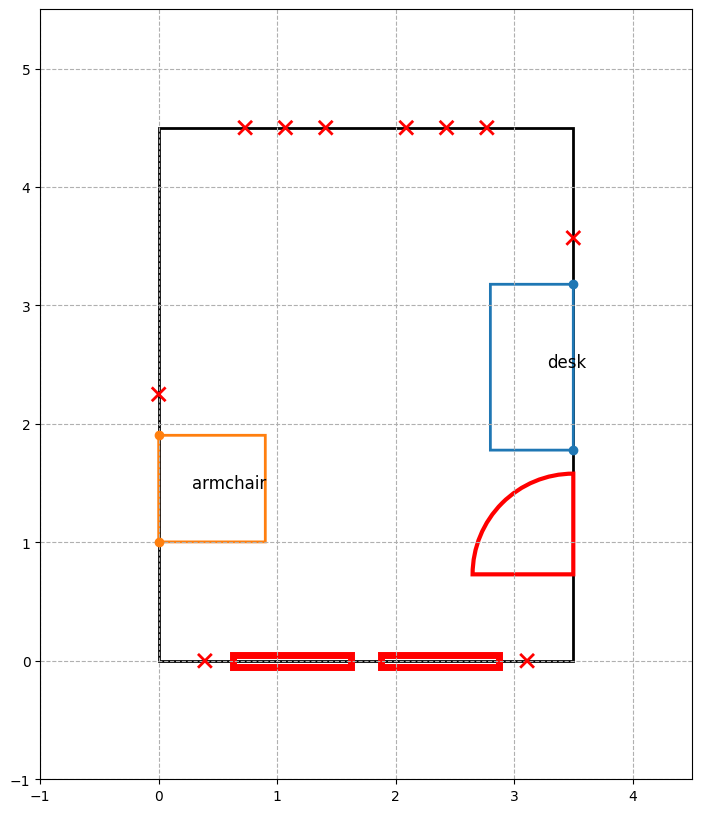

In [35]:
global_context = globals().copy()
local_context = {}
local_context2 = {}
exec(response1, global_context, local_context)

exec(primary_function, global_context, local_context) # define the very first optimizaton function 
## Now want to add in the first primary object
exec(response2) # add in the regions
exec(object_creations[0]) # add in the primary objecta
print("Adding in the primary objects: ", primary_objects)

options = {'maxiter': 200, 'ftol': 1e-6}
iters = 0
min_fun = np.inf
room = local_context[room_name]
func = local_context['optimize_primary_objects']
best_res = None
second_res = None
bounds = Bounds([-1, -1, -np.inf] * len(room.moving_objects), [room.width + 1, room.length + 1, np.inf] * len(room.moving_objects))
while min_fun > 1e-2 and iters < min(len(primary_objects)*100, 300):
    positions = np.zeros((len(room.moving_objects) - len(room.fm_indices)) * 3)
    for i in range(len(room.moving_objects) - len(room.fm_indices)):
        positions[3*i] = np.random.uniform(0, room.width)
        positions[3*i + 1] = np.random.uniform(0, room.length)
        positions[3*i + 2] = np.random.uniform(0, 2*np.pi) 
    res = minimize(func, positions, args = (room), method = 'SLSQP', options = options, bounds = bounds) 

    if iters%50 == 0: 
        print("Iteration:", iters)
        if not best_res:
            print("Cost: ", res.fun, no_overlap(res.x, room), in_bounds(res.x, room))
    iters += 1
    if res.fun < min_fun:
        if not no_overlap(res.x, room) > 0.3 and not in_bounds(res.x, room) > 1e-2:
            min_fun = res.fun
            best_res = res
            print("Iteration:", iters, ", New best result found. Cost: ", min_fun)
    if not second_res:
        second_res = res
    elif second_res and ((res.fun <= second_res.fun) and (in_bounds(res.x, room) <= in_bounds(second_res.x, room) or no_overlap(res.x, room) <= no_overlap(second_res.x, room))): 
        second_res = res

print(iters)
if not best_res: 
    best_res = second_res

for i in range(len(room.fm_indices), len(room.moving_objects)): 
    j = i - len(room.fm_indices)
    room.moving_objects[i].position = (best_res.x[3*j], best_res.x[3*j + 1], best_res.x[3*j + 2]%(2*np.pi))
room.draw() 

for i in range(num_regions):
    room.regions[i].x, room.regions[i].y = room.moving_objects[i].position[0], room.moving_objects[i].position[1]


In [36]:
print(primary_function)

def optimize_primary_objects(positions, room):
    output = 0
    output  += check_and_call('ind_next_to_wall', positions, room, object_index=0)
    output  += check_and_call('ind_accessible', positions, room, object_index=0, sides=['front'], min_dist=1.2)
    output  += check_and_call('ind_close_to_fixed_object', positions, room, object_index=0, fixed_object_type='socket')
    output  += check_and_call('ind_not_block_fixed_object', positions, room, object_index=0, fixed_object_type='door')
    output  += check_and_call('ind_close_to_fixed_object', positions, room, object_index=0, fixed_object_type='window')
    output  += check_and_call('ind_next_to_wall', positions, room, object_index=1)
    output  += check_and_call('ind_accessible', positions, room, object_index=1, sides=['front'])
    output  += check_and_call('ind_not_block_fixed_object', positions, room, object_index=1, fixed_object_type='door')
    output  += check_and_call('ind_close_to_fixed_object', positions, room, object_i

In [37]:
for i in range(len(secondary_functions)):
    print(secondary_functions[i])

def optimize_secondary_objects(positions, room):
    output = 0
    output  += check_and_call('ind_accessible', positions, room, object_index=0, sides=['front'], min_dist=1.2)
    output  += check_and_call('ind_in_region', positions, room, 0, 'Work')
    output  += check_and_call('ind_next_to_wall', positions, room, 0)
    output  += check_and_call('ind_accessible', positions, room, 0, sides=['front'])
    output  += check_and_call('ind_accessible', positions, room, 0, sides=['left'])
    output  += check_and_call('ind_accessible', positions, room, 0, sides=['right'])
    output  += check_and_call('ind_accessible', positions, room, 0, sides=['front'], min_dist=1.5)
    output  += check_and_call('io_next_to', positions, room, 2, 0, side1='front', side2='front')
    output  += check_and_call('io_next_to', positions, room, 3, 0, side1='left', side2='right')
    output  += check_and_call('io_next_to', positions, room, 4, 0)
    output  += check_and_call('io_away_from', positions, room, 1, 

Adding in the secondary objects:  ['desk chair', 'storage cabinet', 'floor plant']


Iteration: 0
Cost:  76.97856208470375 1.1166779643554898 0.009568718728519153
Iteration 9 , New best result found. Cost:  76.2569518943677 overlap:  8.074406862692613e-05 bounds:  1.759360207395061e-09
Iteration 22 , New best result found. Cost:  71.80474764153676 overlap:  0.39333692270613385 bounds:  0.005459430375226488
Iteration: 50
Iteration: 100
Iteration 135 , New best result found. Cost:  71.79339512202479 overlap:  0 bounds:  0.009508497815124244


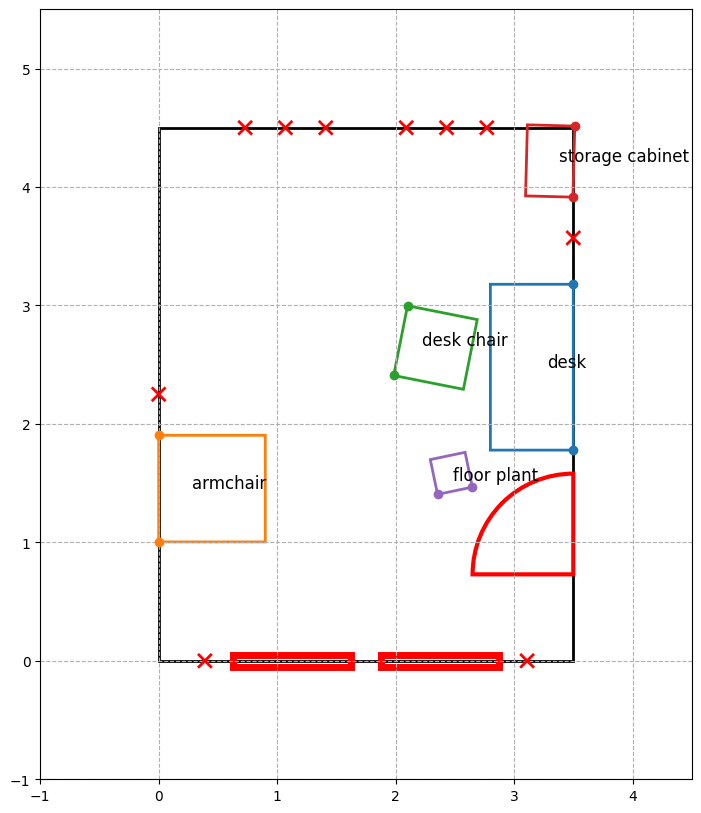

Adding in the secondary objects:  ['bookshelf', 'side table', 'floor lamp']
Iteration: 0
Cost:  63.72243262951727 5.633999685914048 0.14877569620836417
Iteration 3 , New best result found. Cost:  23.291641942360894 overlap:  0 bounds:  0.009508497815124244
Iteration 8 , New best result found. Cost:  18.156466295606663 overlap:  0.015133369011905965 bounds:  0.010081834794031205
Iteration 9 , New best result found. Cost:  14.279751029399526 overlap:  0.08755633200634391 bounds:  0.010958389454223932
Iteration: 50
Iteration 86 , New best result found. Cost:  13.875809147089823 overlap:  0.08754945336412268 bounds:  0.009833094972793676
Iteration: 100
Iteration 118 , New best result found. Cost:  13.875576868623709 overlap:  0.08763507694260661 bounds:  0.009867515395830102


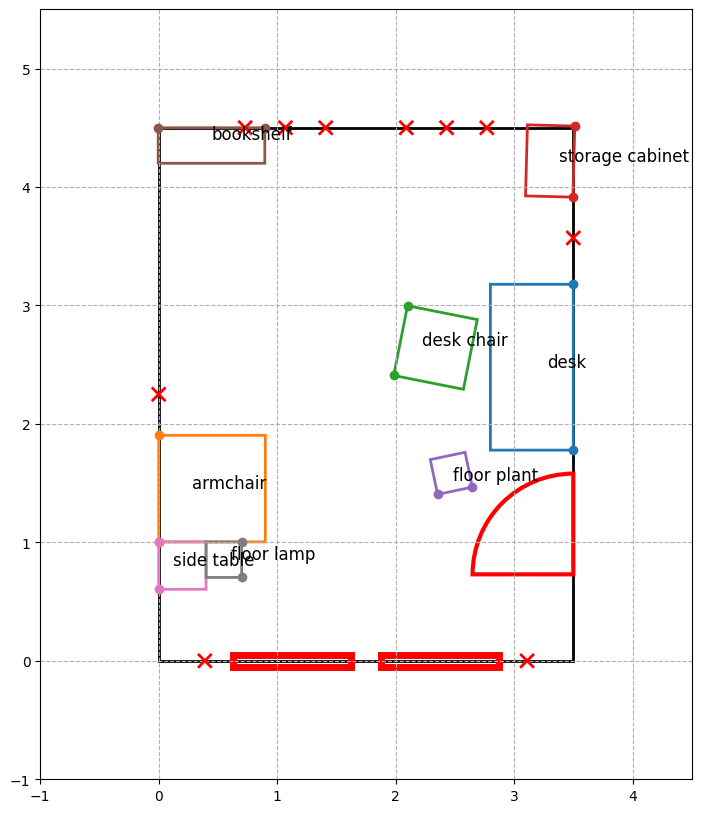

In [38]:
room.moving_objects = room.moving_objects[:num_primary_objects]
room.fm_indices = [i for i in range(num_primary_objects)]
room.tertiary_objects = []
options = {'maxiter': 200, 'ftol': 1e-8}

for region in range(num_regions):
    exec(object_creations[region + 1]) # add in the secondary objects for the region
    exec(secondary_functions[region], global_context, local_context) # define the optimization function for the secondary objects
    room = local_context[room_name]
    func = local_context['optimize_secondary_objects']
    
    print("Adding in the secondary objects: ", [room.moving_objects[i].name for i in objects_per_region[region]][1:])

    num = len(room.moving_objects) - len(room.fm_indices)
    bounds = Bounds([-1] * 3 * num, [room.width + 1, room.length + 1, np.inf] * num)
    iters = 0
    min_fun = np.inf
    best_res2 = None
    second_res = None
    while (min_fun > 1e-2 and best_res2 is None and iters < 400) or (best_res2 and iters < min(num*50, 300)):
        positions = np.zeros(3*num)
        for i in range(num):
            positions[3*i] = np.random.uniform(0, room.width)
            positions[3*i + 1] = np.random.uniform(0, room.length)
            positions[3*i + 2] = np.random.uniform(0, 2*np.pi) 
        res = minimize(func, positions, args = (room), method = 'SLSQP', options = options, bounds = bounds)

        if iters%50 == 0:
            print("Iteration:", iters)
            if not best_res2:
                print("Cost: ", res.fun, no_overlap(res.x, room), in_bounds(res.x, room))
        iters += 1
        if res.fun < min_fun:
            if not no_overlap(res.x, room) > 0.4 and not in_bounds(res.x, room) > 0.1:
                min_fun = res.fun 
                best_res2 = res
                print("Iteration", iters, ", New best result found. Cost: ", min_fun, "overlap: ", no_overlap(res.x, room), "bounds: ", in_bounds(res.x, room))
        if not second_res:
            second_res = res
        elif second_res and ((res.fun <= second_res.fun) and (in_bounds(res.x, room) <= in_bounds(second_res.x, room) or no_overlap(res.x, room) <= no_overlap(second_res.x, room))): 
            second_res = res
    
    if not best_res2: 
        best_res2 = second_res
  
    for i in range(len(room.fm_indices), len(room.moving_objects)): 
        j = i - len(room.fm_indices)
        room.moving_objects[i].position = (best_res2.x[3*j], best_res2.x[3*j + 1], best_res2.x[3*j + 2]%(2*np.pi))

    room.regions[region].x = np.mean([i.position[0] for i in room.moving_objects if i.region == list_region_names[region]])
    room.regions[region].y = np.mean([i.position[1] for i in room.moving_objects if i.region == list_region_names[region]])

    room.draw() 
    plt.show()
    room.fm_indices += [i for i in range(len(room.fm_indices), len(room.moving_objects))]


In [39]:
print(response7)
print(response8)

create_tertiary_object(room=home_office, name='rug', width=1.6, length=2.0, tertiary='floor', index=0)
create_tertiary_object(room=home_office, name='monitor', width=0.6, length=0.2, tertiary='table', index=1)
create_tertiary_object(room=home_office, name='lamp', width=0.2, length=0.2, tertiary='table', index=2)
create_tertiary_object(room=home_office, name='organizer', width=0.3, length=0.2, tertiary='table', index=3)
create_tertiary_object(room=home_office, name='decoration', width=0.2, length=0.2, tertiary='table', index=4)
create_tertiary_object(room=home_office, name='wall_art', width=0.8, length=0.1, tertiary='wall', index=5)
create_tertiary_object(room=home_office, name='rug', width=1.2, length=1.6, tertiary='floor', index=6)
create_tertiary_object(room=home_office, name='bookends', width=0.1, length=0.1, tertiary='table', index=7)
create_tertiary_object(room=home_office, name='vase', width=0.15, length=0.15, tertiary='table', index=8)
create_tertiary_object(room=home_office, na

In [49]:
response7 = "create_tertiary_object(room=room, name='rug', width=1.6, length=2.0, tertiary='floor', index=0)\ncreate_tertiary_object(room=room, name='monitor', width=0.6, length=0.2, tertiary='table', index=1)\ncreate_tertiary_object(room=room, name='lamp', width=0.2, length=0.2, tertiary='table', index=2)\ncreate_tertiary_object(room=room, name='organizer', width=0.3, length=0.2, tertiary='table', index=3)\ncreate_tertiary_object(room=room, name='decoration', width=0.2, length=0.2, tertiary='table', index=4)\ncreate_tertiary_object(room=room, name='wall_art', width=0.8, length=0.1, tertiary='wall', index=5)\ncreate_tertiary_object(room=room, name='rug', width=1.2, length=1.6, tertiary='floor', index=6)\ncreate_tertiary_object(room=room, name='bookends', width=0.1, length=0.1, tertiary='table', index=7)\ncreate_tertiary_object(room=room, name='vase', width=0.15, length=0.15, tertiary='table', index=8)\ncreate_tertiary_object(room=room, name='pillow', width=0.4, length=0.4, tertiary='table', index=9)\ncreate_tertiary_object(room=room, name='wall_art', width=0.7, length=0.1, tertiary='wall', index=10)"

In [50]:
room.tertiary_objects = []
exec(response7)
exec(response8, global_context, local_context)

positions = np.zeros(3*len(room.tertiary_objects))
optimize_tertiary_objects = local_context['optimize_tertiary_objects']
room = local_context[room_name]
options = {'maxiter': 300, 'ftol': 1e-10}
bounds =Bounds([0, 0, -np.inf] * len(room.tertiary_objects), [room.width, room.length, np.inf] * len(room.tertiary_objects))
best_res = None
best_fun = np.inf
for its in range(3 * len(room.tertiary_objects)): 
    for i in range(len(room.tertiary_objects)):
        positions[3*i] = np.random.uniform(0, room.width)
        positions[3*i + 1] = np.random.uniform(0, room.length)
        positions[3*i + 2] = np.random.uniform(0, 2*np.pi) 

    res = minimize(optimize_tertiary_objects, positions, args = (room), method = 'SLSQP', options = options, bounds = bounds)
    if res.fun < best_fun and res.fun > 0:
        print("Iteration", its, ", New best result found. Cost: ", res.fun)
        best_res = res
        best_fun = res.fun

for i in range(len(room.tertiary_objects)): 
    room.tertiary_objects[i].position = (best_res.x[3*i], best_res.x[3*i + 1], best_res.x[3*i + 2]%(2*np.pi))

#room.draw()
end_time = time.time()
elapsed_time = end_time - start_time
print("Time taken: ", elapsed_time)

Iteration 0 , New best result found. Cost:  33.156510372227714
Iteration 1 , New best result found. Cost:  30.31853795771857
Iteration 4 , New best result found. Cost:  6.619728955610868
Iteration 19 , New best result found. Cost:  4.564262530678649
Iteration 30 , New best result found. Cost:  0.7481190907819572
Time taken:  3299.5175342559814


In [51]:
for object in room.moving_objects: 
    print(object.name, object.position, object.width, object.length)

print(" ")
for object in room.fixed_objects: 
    print(object.name, object.position, object.width, object.length)

print(" ")
for object in room.tertiary_objects: 
    print(object.name, object.position, object.width, object.length)


desk (np.float64(3.1499944089055267), np.float64(2.47857485661769), np.float64(1.5707926937043275)) 1.4 0.7
armchair (np.float64(0.4499939218331809), np.float64(1.4537767646641233), np.float64(4.712373011544267)) 0.9 0.9
desk chair (np.float64(2.336533865873733), np.float64(2.64468011526636), np.float64(4.5163848195658165)) 0.6 0.6
storage cabinet (np.float64(3.3046510236172555), np.float64(4.219339702197449), np.float64(1.5445001005760197)) 0.6 0.4
floor plant (np.float64(2.4703601301572773), np.float64(1.5825691605801377), np.float64(0.20659639530654206)) 0.3 0.3
bookshelf (np.float64(0.4457632850680266), np.float64(4.349998330376922), np.float64(3.141606239212887)) 0.9 0.3
side table (np.float64(0.1999835237498644), np.float64(0.8037595649851415), np.float64(4.71254240164467)) 0.4 0.4
floor lamp (np.float64(0.5500285141749648), np.float64(0.8537280802199773), np.float64(1.5712824913576382)) 0.3 0.3
 
door (3.5, 0.73, 1.5707963267948966) 0.85 0.1
window (1.125, 0, 0) 1.0 0.1
window (

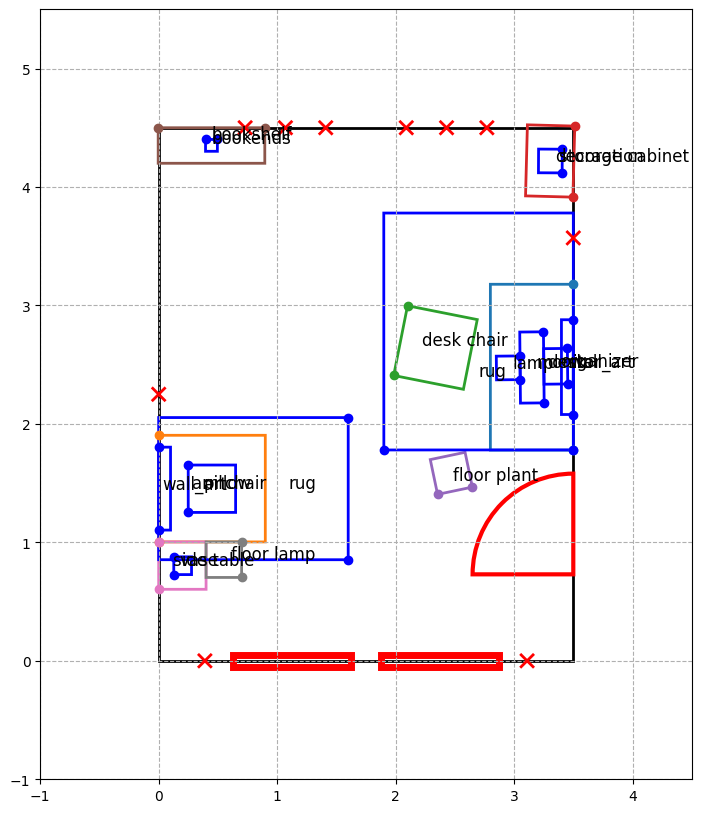

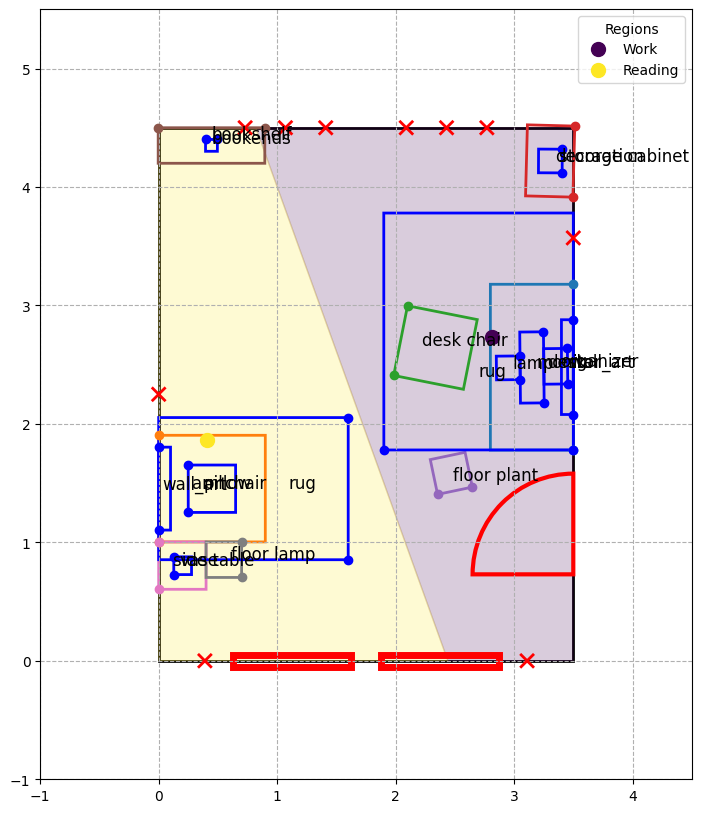

In [52]:
import string

dictionary = {}
ints = 0

dictionary['prompt'] = scene_descriptor
dictionary['room_width'] = room.width
dictionary['room_length'] = room.length

# Function to add objects to dictionary with unique names
def add_objects_to_dict(object_list, ints = 0):
    for obj in object_list:
        if obj.name in dictionary.keys():
            object_name = obj.name + str(ints)
            ints += 1
        else:
            object_name = obj.name
        dictionary[object_name] = {
            'position': obj.position,
            'width': obj.width,
            'length': obj.length
        }

add_objects_to_dict(room.moving_objects)
add_objects_to_dict(room.fixed_objects)
add_objects_to_dict(room.tertiary_objects)

# Add style information
dictionary['style'] = STYLEoutput

# Generate a random filename
res = ''.join(random.choices(string.ascii_letters, k=3))

# Create the folder if it doesn't exist
folder_path = "Result_txt/" + res
os.makedirs(folder_path, exist_ok=True)

# Save the dictionary to a text file
file_path = os.path.join(folder_path, f"{res}.txt")
with open(file_path, 'w') as file:
    for key, value in dictionary.items():
        file.write(f"{key}: {value}\n")

# Save the plot as an image
image_path = os.path.join(folder_path, f"{res}_0.png")
image_path2 = os.path.join(folder_path, f"{res}_1.png")

room.draw()
plt.savefig(image_path)

room.draw(draw_regions = True)
plt.savefig(image_path2)

In [53]:
print("File saved to: ", file_path)

File saved to:  Result_txt/aMT/aMT.txt


## Final Plots

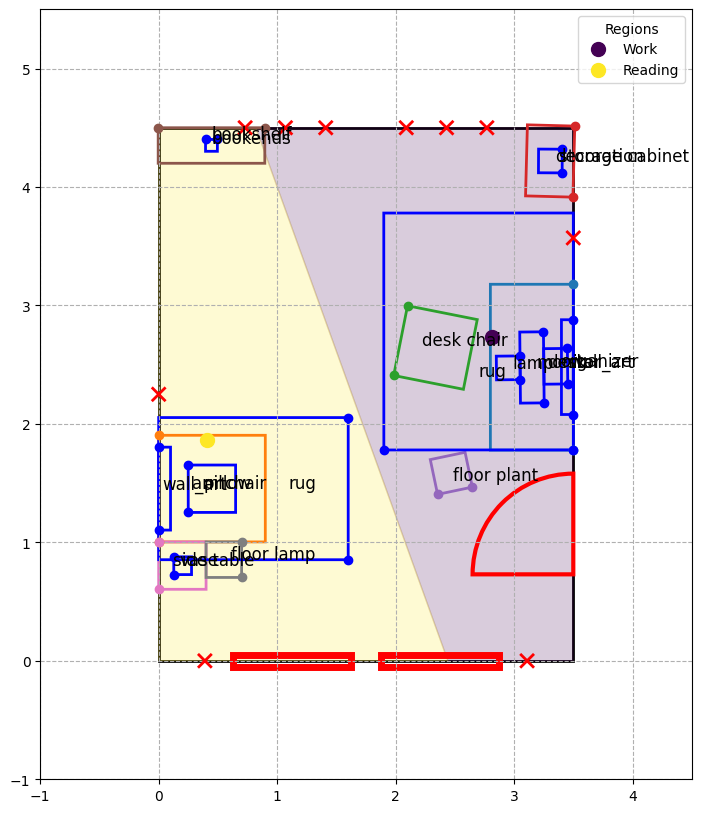

In [54]:
room.draw(draw_regions = True) # uncomment for all objects and regions
#room.draw(level = 0, arrows = True, key = True) # uncomment for primary + secondary objects labelled
#room.draw(level = 1, arrows = True, key = True) # uncomment for tertiary objects labelled

## Metric Evaluation

The Object Overlap Rate (OOR) is:  0.3316801138137465
The Out-Of-Bounds Rate (OOB) is:  0.08148048094428767


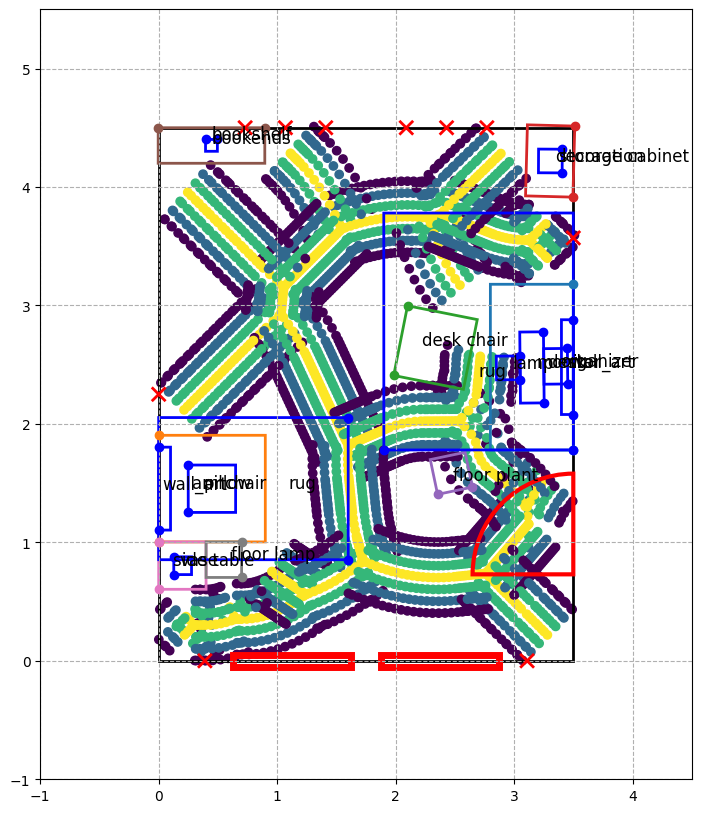

The Pathway Cost (C_p) is:  1.2089127689913741


In [55]:
print("The Object Overlap Rate (OOR) is: ", OOR(room))
print("The Out-Of-Bounds Rate (OOB) is: ", OOB(room))
print("The Pathway Cost (C_p) is: ", pathway_cost(room))